In [124]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from scipy import stats
import utils
import seaborn as sns
import pingouin as pg
import matplotlib.cm as cm

import statsmodels.stats.power as smp
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
from tqdm import tqdm


from natsort import index_natsorted

# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['font.family'] = 'Calibri'

path_figs = "./Figs/"

fingers = ['1', '2', '3', '4', '5']

iti = 1000 # msecs for inter-trial interval
planTime = 2000 # msecs for precue time
feedbackTime = 2000 # msecs for feedback time


total_sub_num = 20
num_sessions = 3
num_blocks_first_session = 4
num_blocks_second_session = 4
num_blocks_third_session = 4
num_blocks_fourth_session = 4
num_trials_per_block = 120
num_trials_baseline = 20

# sub_nums = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
# without Jaimie and Medha
sub_nums = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13]

utils.set_figure_style("1col")
sns.color_palette('colorblind')


[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [125]:
subjs = pd.read_csv(utils.path_misc+'subjs.csv', sep = '\t')

subjs = subjs[subjs['subNum'].isin(sub_nums)].reset_index(drop=True)


In [126]:
subjs.columns

Index(['subNum', 'BN', 'TN', 'trial_num_within_chord', 'TotalTrialNum',
       'targetForce1', 'targetForce2', 'targetForce3', 'targetForce4',
       'targetForce5', 'endForce1', 'endForce2', 'endForce3', 'endForce4',
       'endForce5', 'isTargetVisible', 'endForcePurturbed1',
       'endForcePurturbed2', 'endForcePurturbed3', 'endForcePurturbed4',
       'endForcePurturbed5', 'purturbation1', 'purturbation2', 'forceGain',
       'trialCorr', 'trialErrorType', 'num_targets', 'chord', 'day',
       'block_type', 'count'],
      dtype='str')

# Single Gain Controller: 
Both fingers are controlled by a single gain adaptation state. Therefore, the state-space model would be:

$ X_t (2 by 1 vector) $ produced forces at trial T
$ Y_t (2 by 1 vector) $ observed cursor positions at trial T
$ T (2 by 1 vector) $ target forces of each finger
$ \gamma_t (1 by 1 vector) $ adaptation states at trial T
$ B (1 by 2 vector) $ learning rate 
$ e_t (2 by 1 vector) $ visual error  
$ C (Visual target matrix) $ depends on the targets

In [139]:
# Shared simulation defaults and generator functions (used by all three models below)
SIM_DEFAULTS = dict(
    num_trials=120 * 4,
    epsilon_sigma=0.2,
    A=0.99,
    p_sigma=0.5,
    T=np.diag([-1, 1]),
    targets=np.array([-1, 1]).reshape(2, 1),
)

def _signed_error(Y, targets, T):
    """T @ (Y - targets); equivalent to diag(T) @ (Y-targets) when T is diagonal."""
    return T @ (Y - targets)

def simulate_single_gain(num_trials=None, epsilon_sigma=None, A=None, p_sigma=None,
                         b=0.2, seed=None, **kwargs):
    """Model 1: one shared adaptation state; B rows are identical (rank-1 learning)."""
    cfg = {**SIM_DEFAULTS, **kwargs}
    num_trials = num_trials or cfg['num_trials']
    epsilon_sigma = epsilon_sigma or cfg['epsilon_sigma']
    A = A or cfg['A']
    p_sigma = p_sigma or cfg['p_sigma']
    T, targets = cfg['T'], cfg['targets']
    rng = np.random.default_rng(seed)
    B = np.array([b, b]).reshape(1, 2).repeat(2, axis=0)
    Z_t = np.array([1, 1]).reshape(2, 1)
    records = []
    for i in range(num_trials):
        epsilon_t = rng.normal(0, epsilon_sigma, (2, 1))
        p_t = rng.normal(0, p_sigma, (2, 1))
        X_t = T @ Z_t + epsilon_t
        Y_t = X_t + p_t
        Z_t = A * Z_t - B @ _signed_error(Y_t, targets, T)
        records.append({'trial': i, 'X': np.round(X_t, 2), 'Y': np.round(Y_t, 2),
                        'Z': np.round(Z_t, 2), 'p': np.round(p_t, 2), 'epsilon': np.round(epsilon_t, 2)})
    forces = pd.DataFrame(records)
    return forces, np.array([np.array(x).squeeze() for x in forces['X']]), np.array([np.array(x).squeeze() for x in forces['p']]), T

def simulate_independent_gain(num_trials=None, epsilon_sigma=None, A=None, p_sigma=None,
                              b=0.2, seed=None, **kwargs):
    """Model 2: independent finger-specific adaptation states (diagonal B)."""
    cfg = {**SIM_DEFAULTS, **kwargs}
    num_trials = num_trials or cfg['num_trials']
    epsilon_sigma = epsilon_sigma or cfg['epsilon_sigma']
    A = A or cfg['A']
    p_sigma = p_sigma or cfg['p_sigma']
    T, targets = cfg['T'], cfg['targets']
    rng = np.random.default_rng(seed)
    B = np.diag([b, b])
    Z_t = np.array([1, 1]).reshape(2, 1)
    records = []
    for i in range(num_trials):
        epsilon_t = rng.normal(0, epsilon_sigma, (2, 1))
        p_t = rng.normal(0, p_sigma, (2, 1))
        X_t = T @ Z_t + epsilon_t
        Y_t = X_t + p_t
        Z_t = A * Z_t - B @ _signed_error(Y_t, targets, T)
        records.append({'trial': i, 'X': np.round(X_t, 2), 'Y': np.round(Y_t, 2),
                        'Z': np.round(Z_t, 2), 'p': np.round(p_t, 2), 'epsilon': np.round(epsilon_t, 2)})
    forces = pd.DataFrame(records)
    return forces, np.array([np.array(x).squeeze() for x in forces['X']]), np.array([np.array(x).squeeze() for x in forces['p']]), T

def simulate_ind_plus_common(num_trials=None, epsilon_sigma=None, A=None, p_sigma=None,
                             b_ind=0.2, b_common=0.1, seed=None, **kwargs):
    """Model 3: independent + common adaptation states (estimator targets B_ind + B_common)."""
    cfg = {**SIM_DEFAULTS, **kwargs}
    num_trials = num_trials or cfg['num_trials']
    epsilon_sigma = epsilon_sigma or cfg['epsilon_sigma']
    A = A or cfg['A']
    p_sigma = p_sigma or cfg['p_sigma']
    T, targets = cfg['T'], cfg['targets']
    rng = np.random.default_rng(seed)
    B_ind = np.diag([b_ind, b_ind])
    B_common = np.array([b_common, b_common]).reshape(1, 2).repeat(2, axis=0)
    Z_0 = np.array([0.5, 0.5]).reshape(2, 1)
    Z_t_ind, Z_t_common = Z_0.copy(), Z_0.copy()
    records = []
    for i in range(num_trials):
        epsilon_t = rng.normal(0, epsilon_sigma, (2, 1))
        p_t = rng.normal(0, p_sigma, (2, 1))
        X_t = T @ (Z_t_ind + Z_t_common) + epsilon_t
        Y_t = X_t + p_t
        err = _signed_error(Y_t, targets, T)
        Z_t_ind = A * Z_t_ind - B_ind @ err
        Z_t_common = A * Z_t_common - B_common @ err
        records.append({'trial': i, 'X': np.round(X_t, 2), 'Y': np.round(Y_t, 2),
                        'Z_ind': np.round(Z_t_ind, 2), 'Z_common': np.round(Z_t_common, 2),
                        'p': np.round(p_t, 2), 'epsilon': np.round(epsilon_t, 2)})
    forces = pd.DataFrame(records)
    return forces, np.array([np.array(x).squeeze() for x in forces['X']]), np.array([np.array(x).squeeze() for x in forces['p']]), T

# Effective B matrices recovered by the model-3 estimator for each generative model
B_TRUE = {
    'single': np.array([[0.2, 0.2], [0.2, 0.2]]),
    'independent': np.diag([0.2, 0.2]),
    'ind+common': np.array([[0.3, 0.1], [0.1, 0.3]]),
}


In [140]:
# Generative model: 
# X_t = C * Z_t + e_t
# Z_t+1 = A * Z_t - B * (Y_t - T) 
# Y_t = X_t + p_t
# p_t is external: N(0, std = 0.5N), independent per finger and across trials.
# Y_t is `endForcePurturbed` (produced force + perturbation).

forces, produced_forces, P, T = simulate_single_gain()


In [141]:
forces

,trial,X,Y,Z,p,epsilon
0,0,"[[-0.75], [1.07]]","[[-1.21], [-0.08]]","[[1.16], [1.16]]","[[-0.46], [-1.15]]","[[0.25], [0.07]]"
1,1,"[[-1.39], [1.11]]","[[-2.48], [1.02]]","[[0.85], [0.85]]","[[-1.09], [-0.09]]","[[-0.22], [-0.05]]"
2,2,"[[-0.66], [0.79]]","[[-1.41], [1.16]]","[[0.73], [0.73]]","[[-0.75], [0.37]]","[[0.2], [-0.06]]"
3,3,"[[-0.87], [0.51]]","[[-0.72], [0.6]]","[[0.86], [0.86]]","[[0.16], [0.1]]","[[-0.14], [-0.22]]"
4,4,"[[-1.1], [1.09]]","[[-0.23], [0.46]]","[[1.11], [1.11]]","[[0.87], [-0.63]]","[[-0.24], [0.23]]"
...,...,...,...,...,...,...
475,475,"[[-0.86], [1.29]]","[[-0.32], [1.59]]","[[0.99], [0.99]]","[[0.54], [0.31]]","[[0.12], [0.31]]"
476,476,"[[-1.33], [1.14]]","[[-2.19], [1.39]]","[[0.66], [0.66]]","[[-0.86], [0.25]]","[[-0.34], [0.15]]"
477,477,"[[-0.41], [0.32]]","[[-0.53], [0.95]]","[[0.76], [0.76]]","[[-0.13], [0.63]]","[[0.26], [-0.34]]"
478,478,"[[-0.7], [0.81]]","[[-0.58], [1.37]]","[[0.76], [0.76]]","[[0.12], [0.56]]","[[0.06], [0.05]]"


In [142]:
# produced_forces already returned by simulate_single_gain(); shape (trials, 2)


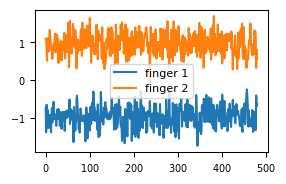

In [143]:
plt.plot(produced_forces[:, 0], label='finger 1')
plt.plot(produced_forces[:, 1], label='finger 2')
plt.legend()


# Two Independent Gain Controller:


In [144]:
# Generative model:
# index and ring seperate:
# X_t(1) = C_1 * Z_t(1) + e_t(1)
# X_t(2) = C_2 * Z_t(2) + e_t(2)
# Z_t+1(1) = A_1 * Z_t(1) - B_1 * (Y_t(1) - T(1))
# Z_t+1(2) = A_2 * Z_t(2) - B_2 * (Y_t(2) - T(2))
# Y_t(1) = X_t(1) + p_t(1)
# Y_t(2) = X_t(2) + p_t(2)

forces, produced_forces, P, T = simulate_independent_gain()


In [145]:
forces

,trial,X,Y,Z,p,epsilon
0,0,"[[-0.39], [0.99]]","[[-0.86], [0.78]]","[[1.02], [1.03]]","[[-0.48], [-0.21]]","[[0.61], [-0.01]]"
1,1,"[[-0.91], [1.13]]","[[-0.09], [1.01]]","[[1.19], [1.02]]","[[0.82], [-0.12]]","[[0.11], [0.09]]"
2,2,"[[-0.87], [1.05]]","[[-1.11], [1.22]]","[[1.16], [0.97]]","[[-0.24], [0.17]]","[[0.32], [0.03]]"
3,3,"[[-1.14], [0.96]]","[[-1.75], [0.45]]","[[1.0], [1.07]]","[[-0.6], [-0.51]]","[[0.01], [-0.0]]"
4,4,"[[-0.97], [0.82]]","[[-0.83], [0.93]]","[[1.02], [1.07]]","[[0.14], [0.12]]","[[0.03], [-0.25]]"
...,...,...,...,...,...,...
475,475,"[[-0.99], [1.0]]","[[-0.3], [0.7]]","[[1.0], [0.81]]","[[0.69], [-0.3]]","[[-0.12], [0.24]]"
476,476,"[[-0.63], [0.68]]","[[-0.62], [1.18]]","[[1.06], [0.77]]","[[0.01], [0.5]]","[[0.37], [-0.13]]"
477,477,"[[-1.08], [0.53]]","[[-1.31], [0.49]]","[[0.99], [0.86]]","[[-0.24], [-0.04]]","[[-0.01], [-0.24]]"
478,478,"[[-0.7], [0.81]]","[[-1.27], [-0.22]]","[[0.93], [1.1]]","[[-0.57], [-1.03]]","[[0.29], [-0.05]]"


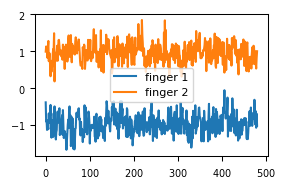

In [146]:
produced_forces = np.array(list(forces['X']))
plt.plot(produced_forces[:, 0], label='finger 1')
plt.plot(produced_forces[:, 1], label='finger 2')
plt.legend()


# Two independent + commmon gain controller:

In [147]:
# Generative model:
# Both seperate and commmon components:

forces, produced_forces, P, T = simulate_ind_plus_common()


In [148]:
P.shape

(480, 2)

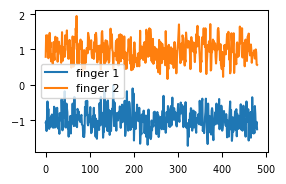

In [149]:
plt.plot(produced_forces[:, 0], label='finger 1')
plt.plot(produced_forces[:, 1], label='finger 2')
plt.legend()


In [150]:
# estimating the learning rate:

# X_t+1 = T * (Z_t+1_ind + Z_t+1_common) + e_t+1
# cov(P_t, X_t+1) = T * (cov(P_t, Z_t+1_ind) + cov(P_t, Z_t+1_common))
# ===> cov(P_t, Z_t+1_ind) = cov(P_t, A * Z_t_ind - B_ind * T * (Y_t - targets))
# = cov(P_t, - B_ind * T * P_t) = - B_ind * T * cov(P_t, P_t) (1)


# cov(P_t, Z_t+1_common) = cov(P_t, A * Z_t_common - B_common * T * (Y_t - targets)
# = -B_common * T * cov(P_t, P_t) (2)

# cov(P_t, X_t+1) = - T * (B_ind + B_common) * T * cov(P_t, P_t) (3)

# ===> (B_ind + B_common) = - T @ cov(P_t, X_t) @ np.linalg.pinv(T @ cov(P_t, P_t)) (4)

def estimate_learning_rate(X, P, T):
    lagged_X = X[1:]
    P_t = P[:-1]
    cov_X_P = np.cov(lagged_X.T, P_t.T)
    cov_X_P = cov_X_P[:2, 2:] # shape (2, 2)
    var_P = np.cov(P_t.T) # shape (2, 2)

    # T^-1 = T
    # cov_X_P = - T @ B * T * var_P
    # cov_X_P * var_P^-1 = - T @ B * T
    # - T @ cov_X_P * var_P^-1 * T = B
    B = - T @ cov_X_P @ np.linalg.pinv(var_P) @ T
    return B

produced_forces = produced_forces.squeeze()
P = P.squeeze()

B = estimate_learning_rate(produced_forces, P, T)
print('Single-run estimate (model 3 generative data):')
print(B)
print('True B_ind + B_common:')
print(B_TRUE['ind+common'])


Single-run estimate (model 3 generative data):
[[0.29036571 0.0689355 ]
 [0.11847142 0.32453626]]
True B_ind + B_common:
[[0.3 0.1]
 [0.1 0.3]]


In [159]:
SIMULATORS = {
    'single': simulate_single_gain,
    'independent': simulate_independent_gain,
    'ind+common': simulate_ind_plus_common,
}

def summarize_B(B_hat, B_true):
    """Scalar summaries that help distinguish controller architectures."""
    off_diag = 0.5 * (B_hat[0, 1] + B_hat[1, 0])
    on_diag = 0.5 * (B_hat[0, 0] + B_hat[1, 1])
    row_diff = np.linalg.norm(B_hat[0] - B_hat[1])
    return {
        'B00': B_hat[0, 0], 'B01': B_hat[0, 1],
        'B10': B_hat[1, 0], 'B11': B_hat[1, 1],
        'off_diag': off_diag,
        'on_diag': on_diag,
        # 'row_diff': row_diff,
        # 'fro_bias': np.linalg.norm(B_hat - B_true, 'fro'),
    }

n_rep = 500
rows = []
B_hats = {model: [] for model in SIMULATORS}

for model_name, simulator in tqdm(SIMULATORS.items(), desc='models'):
    B_true = B_TRUE[model_name]
    for seed in range(n_rep):
        _, X, P, T = simulator(seed=seed)
        B_hat = estimate_learning_rate(X, P, T)
        B_hats[model_name].append(B_hat)
        rows.append({'model': model_name, 'seed': seed, **summarize_B(B_hat, B_true)})

mc = pd.DataFrame(rows)

print('Mean estimated B (model-3 estimator):')
for model_name in SIMULATORS:
    print(f"\n{model_name}:")
    print(np.mean(B_hats[model_name], axis=0))
    print('true:')
    print(B_TRUE[model_name])



models: 100%|██████████| 3/3 [00:10<00:00,  3.66s/it]

Mean estimated B (model-3 estimator):

single:
[[0.19963302 0.20032662]
 [0.19940664 0.20030737]]
true:
[[0.2 0.2]
 [0.2 0.2]]

independent:
[[0.19852185 0.00056061]
 [0.00074029 0.19951797]]
true:
[[0.2 0. ]
 [0.  0.2]]

ind+common:
[[0.29839794 0.10080971]
 [0.10064114 0.29980599]]
true:
[[0.3 0.1]
 [0.1 0.3]]


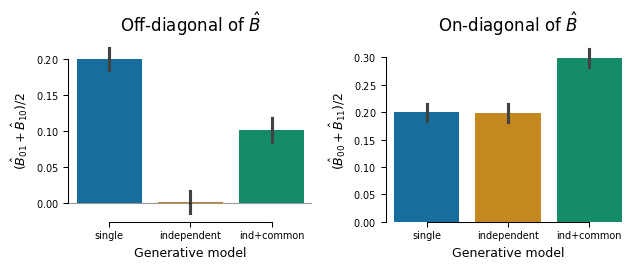

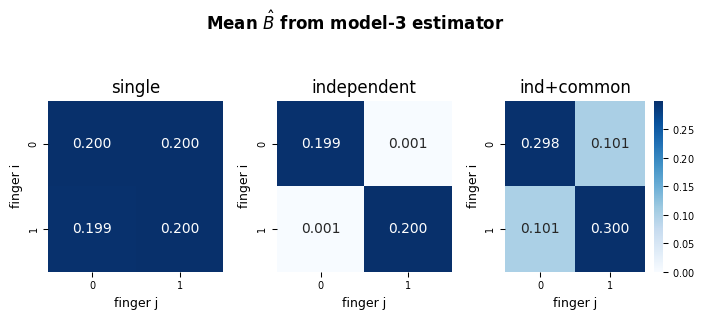

In [174]:
fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.8))

palette = {'single': sns.color_palette('colorblind')[0],
           'independent': sns.color_palette('colorblind')[1],
           'ind+common': sns.color_palette('colorblind')[2]}

sns.barplot(data = mc, x = 'model', y = 'off_diag', order = ['single', 'independent', 'ind+common'],
            palette = palette, ax = axes[0], errorbar = 'sd', hue = 'model')
axes[0].axhline(0, color='k', lw=0.8, alpha=0.4)
axes[0].set_title('Off-diagonal of $\\hat{B}$')
axes[0].set_xlabel('Generative model')
axes[0].set_ylabel('$(\\hat{B}_{01}+\\hat{B}_{10})/2$')

sns.barplot(data = mc, x = 'model', y = 'on_diag', order = ['single', 'independent', 'ind+common'],
            palette = palette, ax = axes[1], errorbar = 'sd', hue = 'model')
axes[1].set_title('On-diagonal of $\\hat{B}$')
axes[1].set_xlabel('Generative model')
axes[1].set_ylabel('$(\\hat{B}_{00}+\\hat{B}_{11})/2$')

sns.despine(trim = True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(7.2, 3))
for ax, model_name in zip(axes, SIMULATORS):
    B_mean = np.mean(B_hats[model_name], axis=0)
    sns.heatmap(B_mean, annot=True, fmt='.3f', cmap='Blues',
                vmin=0, cbar=ax is axes[-1], ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel('finger j')
    ax.set_ylabel('finger i')
plt.suptitle('Mean $\\hat{B}$ from model-3 estimator', y=1.05)
plt.tight_layout()
plt.show()
